In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_2A, PATHWAYS_3

data = "dream_cytof"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename="evaluate_all_figure3"), index_col=0).assign(model=model)
    for model in PATHWAYS_3
)
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

df2 = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename="evaluate_all_figure2a"), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)
val_df2 = df2[df2.dataset == "val"]
val_df2.features.fillna("None", inplace=True)

model1 = "EGFR_MAPK__logobs"

df1 = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model1, data=data, filename="evaluate_all_figure1a"), index_col=0)
df1.model.fillna(model1, inplace=True)  # single model investigated in this batch of runs

val_df1 = df1[df1.dataset == "val"]
val_df1.features.fillna("None", inplace=True)

In [2]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.mean()

model                            context             
EGFR_MAPK__logobs                cytof_init              0.527314
                                 cytof_init_plus_intr    0.514161
                                 cytof_init_plus_lb      0.516484
EGFR_MAPK__logobs_perbb2_aggavg  cytof_init              0.535913
                                 cytof_init_plus_intr    0.493795
                                 cytof_init_plus_lb      0.537805
EGFR_MAPK__logobs_tegfr_aggavg   cytof_init              0.455936
                                 cytof_init_plus_intr    0.486095
                                 cytof_init_plus_lb      0.457328
EGFR_MAPK__logobs_terbb2_aggavg  cytof_init              0.538561
                                 cytof_init_plus_intr    0.497681
                                 cytof_init_plus_lb      0.524107
Name: rmse, dtype: float64

In [3]:
val_df[val_df.ref == "DMM"].groupby(["model", "context"]).rmse.median()

model                            context             
EGFR_MAPK__logobs                cytof_init              0.519751
                                 cytof_init_plus_intr    0.477273
                                 cytof_init_plus_lb      0.488643
EGFR_MAPK__logobs_perbb2_aggavg  cytof_init              0.536523
                                 cytof_init_plus_intr    0.470058
                                 cytof_init_plus_lb      0.503376
EGFR_MAPK__logobs_tegfr_aggavg   cytof_init              0.490659
                                 cytof_init_plus_intr    0.495072
                                 cytof_init_plus_lb      0.473172
EGFR_MAPK__logobs_terbb2_aggavg  cytof_init              0.567801
                                 cytof_init_plus_intr    0.496986
                                 cytof_init_plus_lb      0.517932
Name: rmse, dtype: float64

# Inconsistent perbb2_aggavg scores w.r.t. `wandb` 61_fig3 project (https://wandb.ai/lab_frohlich/DeepMechanisticModels.v61_fig3.dream_cytof?nw=nwusergiacomofabrini)

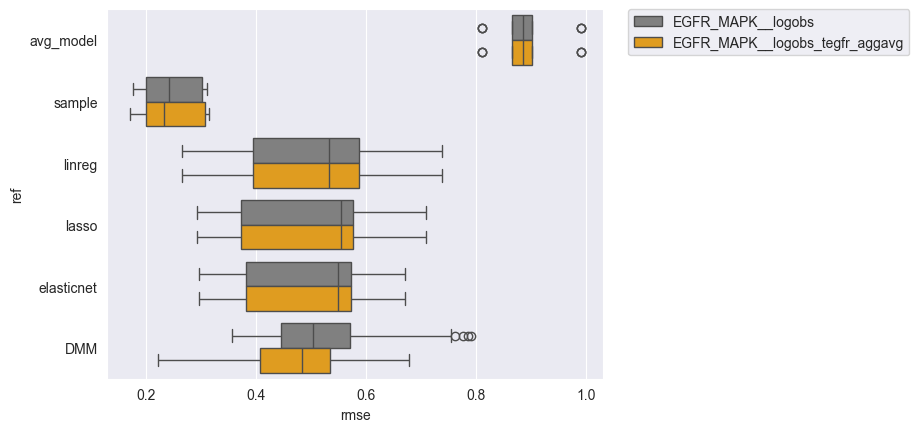

In [4]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
}

sns.boxplot(
    val_df[val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"])],
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

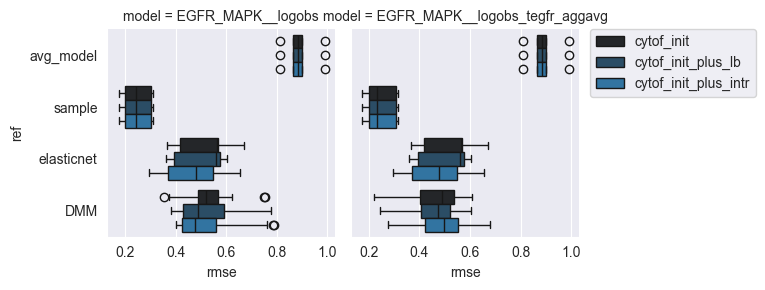

In [5]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
}

g = sns.FacetGrid(
    val_df[val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"])],
    col="model",
    col_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "elasticnet", "DMM"],
    hue="context",
    hue_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"]
    # palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

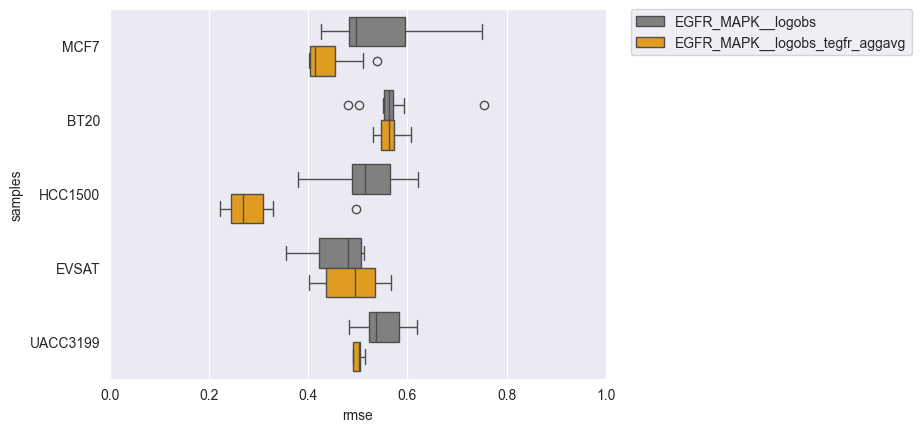

In [6]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
}

sns.boxplot(
    val_df[(val_df.ref == "DMM") & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"])) & (val_df.context == 'cytof_init')],
    y="samples",
    x="rmse",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [7]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    num_contexts = int(len(df['context'].unique()))
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}; < 0.05/{num_contexts}={0.05/num_contexts}?: {p_value < 0.05/num_contexts}")

# There is a statistically significant difference (improvement) from `__logobs` to `__logobs_tegfr_aggavg`, but not to `__logobs_tegfr_aggavg_pobs`

In [8]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_lb - Kruskal-Wallis H-test: H-statistic=4.78, p-value=0.0289; < 0.05/3=0.016666666666666666?: False
Context: cytof_init_plus_intr - Kruskal-Wallis H-test: H-statistic=0.33, p-value=0.5672; < 0.05/3=0.016666666666666666?: False
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=9.84, p-value=0.0017; < 0.05/3=0.016666666666666666?: True


# `cytof_init` improves significantly going from `__logobs` to `__logobs_tegfr_aggavg` (even with multiple-testing correction)

In [9]:
groups = [
    val_df[
        (val_df.ref.isin(["DMM"])) & (val_df.context == 'cytof_init')
        & (val_df.model.isin(["EGFR_MAPK__logobs",]))
    ].sort_values(by=["context", "samples", "job"]).rmse.values,
    val_df[
        (val_df.ref.isin(["DMM"])) & (val_df.context == 'cytof_init')
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
    ].sort_values(by=["context", "samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=226.0, p=3.289e-05


In [10]:
groups = [
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs",]))
    ].sort_values(by=["context", "samples", "job"]).rmse.values,
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
    ].sort_values(by=["context", "samples", "job"]).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}, adjusted p-value: {p*3}")

Wilcoxon signed-rank: W=2636.0, p=1.359e-08, adjusted p-value: 4.077889895986396e-08


In [11]:
val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))].groupby(["model", "context"]).rmse.mean()

model                           context             
EGFR_MAPK__logobs               cytof_init              0.527314
                                cytof_init_plus_intr    0.514161
                                cytof_init_plus_lb      0.516484
EGFR_MAPK__logobs_tegfr_aggavg  cytof_init              0.455936
                                cytof_init_plus_intr    0.486095
                                cytof_init_plus_lb      0.457328
Name: rmse, dtype: float64

# Overall, all contexts considered, there is a stat. significant improvement between `__logobs` and `__logobs_tegfr_aggavg`

In [12]:
val_df[(val_df.ref.isin(["DMM", "elasticnet"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))].groupby(["ref", "model", "context"]).rmse.mean()

ref         model                           context             
DMM         EGFR_MAPK__logobs               cytof_init              0.527314
                                            cytof_init_plus_intr    0.514161
                                            cytof_init_plus_lb      0.516484
            EGFR_MAPK__logobs_tegfr_aggavg  cytof_init              0.455936
                                            cytof_init_plus_intr    0.486095
                                            cytof_init_plus_lb      0.457328
elasticnet  EGFR_MAPK__logobs               cytof_init              0.517487
                                            cytof_init_plus_intr    0.469915
                                            cytof_init_plus_lb      0.498801
            EGFR_MAPK__logobs_tegfr_aggavg  cytof_init              0.517487
                                            cytof_init_plus_intr    0.469915
                                            cytof_init_plus_lb      0.498801
Name: rmse,

In [13]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM", "elasticnet"])) & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg"]))],
    "rmse",
    "ref"
)

Context: cytof_init_plus_lb - Kruskal-Wallis H-test: H-statistic=1.05, p-value=0.3055; < 0.05/3=0.016666666666666666?: False
Context: cytof_init_plus_intr - Kruskal-Wallis H-test: H-statistic=0.05, p-value=0.8148; < 0.05/3=0.016666666666666666?: False
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=1.44, p-value=0.2300; < 0.05/3=0.016666666666666666?: False


In [14]:
groups = [
    val_df[
        val_df.ref.isin(["DMM"])
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
        & (val_df.context == "cytof_init")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean().values,
    val_df[
        val_df.ref.isin(["elasticnet"])
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
        & (val_df.context == "cytof_init")
    ].sort_values(
        by=["context", "samples"]
    ).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=5.0, p=0.625


In [15]:
val_df[
        val_df.ref.isin(["DMM"])
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
        & (val_df.context == "cytof_init")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean()

context     samples 
cytof_init  BT20        0.563503
            EVSAT       0.486492
            HCC1500     0.291430
            MCF7        0.438816
            UACC3199    0.499438
Name: rmse, dtype: float64

In [16]:
val_df[
        val_df.ref.isin(["elasticnet"])
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
        & (val_df.context == "cytof_init")
    ].sort_values(
        by=["context", "samples"]
    )[["samples", "rmse"]]

,samples,rmse
85,BT20,0.565474
88,EVSAT,0.670333
91,HCC1500,0.568282
94,MCF7,0.416844
97,UACC3199,0.366501


# But it's not statistically significantly better than the linear regressors....

# We can now compare the tEGFR modification to the fEGFR with added tEGFR via context

In [17]:
from training_configuration import PATHWAYS_2A

data = "dream_cytof"
filename2= "evaluate_all_figure2a"

df2 = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename2), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)
val_df2 = df2[df2.dataset == "val"]
val_df2.features.fillna("None", inplace=True)
val_df2 = val_df2[val_df2.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]

In [18]:
val_df2_fegfr_cytof_tegfr = val_df2[(val_df2.model == "EGFR_MAPK__logobs_fegfr_aggavg")]

In [19]:
df_comp = pd.concat(
    [
        val_df[val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg"])],
        val_df2_fegfr_cytof_tegfr
    ]
)

In [20]:
df_comp.context.unique()

array(['cytof_init_plus_lb', 'cytof_init_plus_intr', 'cytof_init',
       'cytof_init_plus_pEGFR', 'cytof_init_plus_tEGFR',
       'cytof_init_plus_tEGFR_pEGFR'], dtype=object)

In [21]:
for context in ["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_lb"]:
    groups = [
        df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].sort_values(by="job").rmse.values,
        df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin([context])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="job").rmse.values,
    ]
    stat, p = stats.wilcoxon(*groups, alternative="two-sided")
    print(f"{context}, Wilcoxon signed-rank: W={stat}, p={p:.4g}; p-value={p:.4f}; < 0.05/{3}={0.05/3}?: {p < 0.05/3}")

cytof_init, Wilcoxon signed-rank: W=212.0, p=1.603e-05; p-value=0.0000; < 0.05/3=0.016666666666666666?: True
cytof_init_plus_tEGFR, Wilcoxon signed-rank: W=377.0, p=0.0112; p-value=0.0112; < 0.05/3=0.016666666666666666?: True
cytof_init_plus_lb, Wilcoxon signed-rank: W=553.0, p=0.4207; p-value=0.4207; < 0.05/3=0.016666666666666666?: False


# Upon single test, the difference between tEGFR + fegfr model and basic cytof in tegfr model would be significant...not if we correct for multiple testing though....it's also not significant from the start in case of comparison with `cytof_plus_lb` with the `fegfr` model

In [22]:
df_comp.groupby(["model", "context"]).rmse.mean()

model                           context                    
EGFR_MAPK__logobs_fegfr_aggavg  cytof_init                     0.574749
                                cytof_init_plus_intr           0.539897
                                cytof_init_plus_lb             0.501257
                                cytof_init_plus_pEGFR          0.514527
                                cytof_init_plus_tEGFR          0.514311
                                cytof_init_plus_tEGFR_pEGFR    0.511084
EGFR_MAPK__logobs_tegfr_aggavg  cytof_init                     0.483948
                                cytof_init_plus_intr           0.493602
                                cytof_init_plus_lb             0.481246
Name: rmse, dtype: float64

# There is no statistical difference, but embedding tEGFR levels in the mechanistic model performs slightly better than passing them as input context. We can also see that the tEGFR information is helpful to regressors, as their performance drops when moving from `fEGFR` with added tEGFR context to `tEGFR` without it.

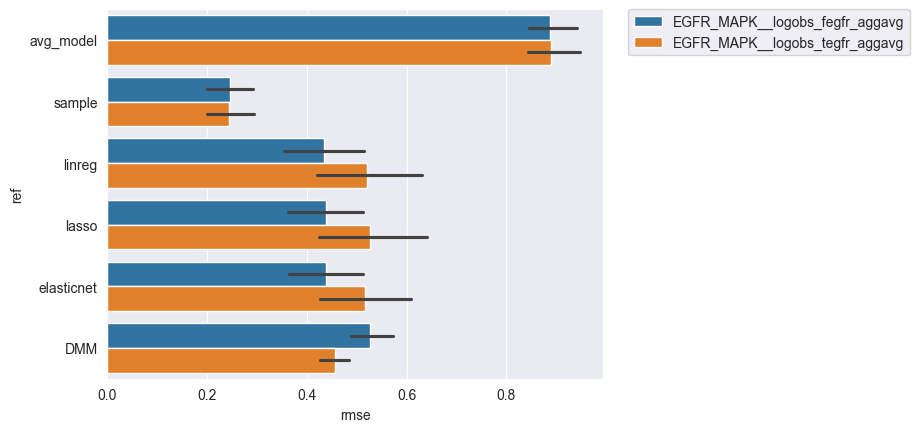

In [23]:
sns.barplot(
    df_comp[
        ((df_comp.context == "cytof_init") & (df_comp.model == "EGFR_MAPK__logobs_tegfr_aggavg"))
        |
        ((df_comp.context == "cytof_init_plus_tEGFR") & (df_comp.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

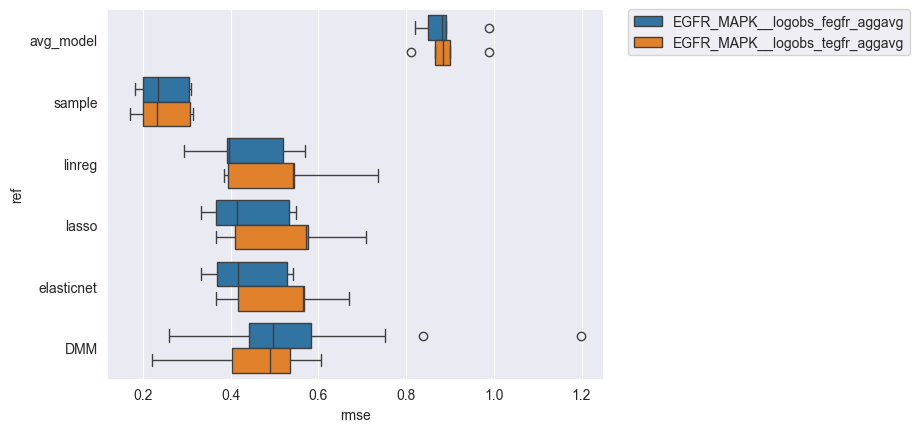

In [24]:
sns.boxplot(
    df_comp[
        ((df_comp.context == "cytof_init") & (df_comp.model == "EGFR_MAPK__logobs_tegfr_aggavg"))
        |
        ((df_comp.context == "cytof_init_plus_tEGFR") & (df_comp.model == "EGFR_MAPK__logobs_fegfr_aggavg"))
    ],
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [25]:
groups = [
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].groupby("samples").rmse.mean().reset_index().sort_values(by="samples").rmse.values,
    df_comp[(df_comp.ref.isin(["elasticnet"])) & (df_comp.context.isin(["cytof_init_plus_tEGFR"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="samples").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=6.0, p=0.8125


# No statistically significant difference between elasticnet with added tEGFR and DMMs without (but tEGFR in mechanistic model)...but the mean RMSE is still higher for the DMMs...

In [42]:
comp_df = val_df[
    (val_df.ref.isin(["avg_model", "elasticnet", "DMM", "sample"])) &  # only include updated model
    (val_df.context.isin(["cytof_init", "cytof_init_plus_lb",])) &
    (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
]

print(comp_df.shape)
comp_df = pd.concat(
    [
        comp_df,
        # Only keep elasticnet and DMM for multimodal and cytof_init contexts
        val_df1[
            (((val_df1.context == "multimodal") & (val_df1.features == "best_RFE_10_permute")) | ((val_df1.context == "cytof_init") & (val_df1.features == "RFE_10_permute")))
            & (val_df1.ref.isin(["DMM", "elasticnet"]))
        ],
        val_df2[
            (val_df2.context.isin(["cytof_init_plus_tEGFR", "cytof_init_plus_lb"]))
            & (val_df2.model == "EGFR_MAPK__logobs_fegfr_aggavg")
            & (val_df2.features == "RFE_10_permute") & (val_df2.ref.isin(["DMM", "elasticnet"]))
        ]
    ]
)

comp_df

(130, 16)


,dataset,ref,model,samples,context,features,n_hidden,depth,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse
203,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,EVSAT,cytof_init_plus_lb,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,3.0,500.0,3.0,0.470876
202,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,EVSAT,cytof_init_plus_lb,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,2.0,500.0,3.0,0.507660
201,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,EVSAT,cytof_init_plus_lb,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,1.0,500.0,3.0,0.523825
200,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,EVSAT,cytof_init_plus_lb,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,0.0,500.0,3.0,0.522235
204,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,EVSAT,cytof_init_plus_lb,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,4.0,500.0,3.0,0.468428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,val,elasticnet,EGFR_MAPK__logobs_fegfr_aggavg,EVSAT,cytof_init_plus_tEGFR,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.542594
260,val,elasticnet,EGFR_MAPK__logobs_fegfr_aggavg,BT20,cytof_init_plus_tEGFR,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.529303
210,val,elasticnet,EGFR_MAPK__logobs_fegfr_aggavg,BT20,cytof_init_plus_lb,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.558561
216,val,elasticnet,EGFR_MAPK__logobs_fegfr_aggavg,HCC1500,cytof_init_plus_lb,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.577109


In [43]:
import numpy as np

comp_df["group"] = np.where(
    comp_df["ref"].isin(["avg_model", "sample"]),
    comp_df["ref"],  # case 1: avg_model / sample
    np.where(
        comp_df["ref"] == "elasticnet",
        comp_df["ref"] + "_" + comp_df["context"],  # case 2: elasticnet -> ref+context
        comp_df["model"] + "_" + comp_df["ref"] + "_" + comp_df["context"]  # case 3: all others
    )
)
comp_df.group.unique()

array(['EGFR_MAPK__logobs_tegfr_aggavg_DMM_cytof_init_plus_lb',
       'EGFR_MAPK__logobs_tegfr_aggavg_DMM_cytof_init', 'avg_model',
       'elasticnet_cytof_init_plus_lb', 'elasticnet_cytof_init', 'sample',
       'EGFR_MAPK__logobs_DMM_multimodal',
       'EGFR_MAPK__logobs_DMM_cytof_init', 'elasticnet_multimodal',
       'EGFR_MAPK__logobs_fegfr_aggavg_DMM_cytof_init_plus_tEGFR',
       'EGFR_MAPK__logobs_fegfr_aggavg_DMM_cytof_init_plus_lb',
       'elasticnet_cytof_init_plus_tEGFR'], dtype=object)

In [29]:
val_df.groupby(["ref", "model", "context"]).rmse.mean()

ref     model                            context             
DMM     EGFR_MAPK__logobs                cytof_init              0.527314
                                         cytof_init_plus_intr    0.514161
                                         cytof_init_plus_lb      0.516484
        EGFR_MAPK__logobs_perbb2_aggavg  cytof_init              0.535913
                                         cytof_init_plus_intr    0.493795
                                                                   ...   
sample  EGFR_MAPK__logobs_tegfr_aggavg   cytof_init_plus_intr    0.244588
                                         cytof_init_plus_lb      0.244588
        EGFR_MAPK__logobs_terbb2_aggavg  cytof_init              0.254043
                                         cytof_init_plus_intr    0.254043
                                         cytof_init_plus_lb      0.254043
Name: rmse, Length: 72, dtype: float64

# Exclude fEGFR model

In [62]:
comp_df = val_df[
    (val_df.ref.isin(["avg_model", "DMM", "sample"])) &
    (val_df.context.isin(["cytof_init",])) &
    (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))
]

print(comp_df.shape)
comp_df = pd.concat(
    [
        comp_df,
        # Only keep elasticnet and DMM for multimodal and cytof_init contexts
        val_df1[
            (((val_df1.context == "multimodal") & (val_df1.features == "best_RFE_10_permute")) | ((val_df1.context == "cytof_init") & (val_df1.features == "RFE_10_permute")))
            & (val_df1.ref.isin(["DMM", "elasticnet"]))
        ]
    ]
)

comp_df

(60, 16)


,dataset,ref,model,samples,context,features,n_hidden,depth,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse
219,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,9.0,500.0,3.0,0.312652
218,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,8.0,500.0,3.0,0.230353
217,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,7.0,500.0,3.0,0.276222
216,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,6.0,500.0,3.0,0.221449
215,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_10_permute,2.0,0.0,0.01,0.0,0.01,200.0,5.0,500.0,3.0,0.328300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,val,elasticnet,EGFR_MAPK__logobs,BT20,multimodal,best_RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.566790
137,val,elasticnet,EGFR_MAPK__logobs,UACC3199,cytof_init,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.366501
134,val,elasticnet,EGFR_MAPK__logobs,MCF7,cytof_init,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.416844
131,val,elasticnet,EGFR_MAPK__logobs,HCC1500,cytof_init,RFE_10_permute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.568282


In [63]:
import numpy as np

comp_df["group"] = np.where(
    comp_df["ref"].isin(["avg_model", "sample"]),
    comp_df["ref"],  # case 1: avg_model / sample
    np.where(
        comp_df["ref"] == "elasticnet",
        comp_df["ref"] + "_" + comp_df["context"],  # case 2: elasticnet -> ref+context
        comp_df["model"] + "_" + comp_df["ref"] + "_" + comp_df["context"]  # case 3: all others
    )
)
comp_df.group.unique()

array(['EGFR_MAPK__logobs_tegfr_aggavg_DMM_cytof_init', 'avg_model',
       'sample', 'EGFR_MAPK__logobs_DMM_multimodal',
       'EGFR_MAPK__logobs_DMM_cytof_init', 'elasticnet_multimodal',
       'elasticnet_cytof_init'], dtype=object)

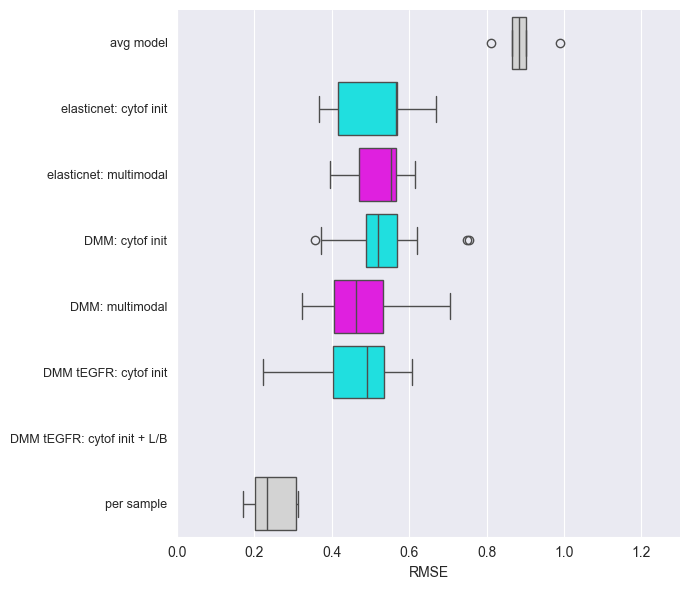

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- choose exactly the combos you want to display ---
want_elasticnet_contexts = ["cytof_init", "multimodal"]
want_dmm_logobs = ["cytof_init", "multimodal"]
want_dmm_tegfr = ["cytof_init"]

df = comp_df.copy()

# Build a single display label per row
def mk_label(r):
    if r["ref"] == "avg_model":
        return "avg model"
    if r["ref"] == "sample":
        return "per sample"
    if r["ref"] == "elasticnet":
        if r["context"] in want_elasticnet_contexts:
            return f"elasticnet: {r['context'].replace('_', ' ')}"
        else:
            return None
    if r["ref"] == "DMM":
        if r["model"] == "EGFR_MAPK__logobs" and r["context"] in want_dmm_logobs:
            return f"DMM: {r['context'].replace('_', ' ').replace('plus', '+').replace('lb', 'L/B')}"
        if r["model"] == "EGFR_MAPK__logobs_fegfr_aggavg" and r["context"] in want_dmm_fegfr:
            return f"DMM fEGFR: {r['context'].replace('_', ' ').replace('plus', '+').replace('lb', 'L/B')}"
        if r["model"] == "EGFR_MAPK__logobs_tegfr_aggavg" and r["context"] in want_dmm_tegfr:
            return f"DMM tEGFR: {r['context'].replace('_', ' ').replace('plus', '+').replace('lb', 'L/B')}"
        return None
    # drop anything else
    return None

df["display_group"] = df.apply(mk_label, axis=1)
plot_df = df.dropna(subset=["display_group"]).copy()

# Order exactly as requested
order = [
    "avg model",
    "elasticnet: cytof init",
    "elasticnet: multimodal",
    "DMM: cytof init", "DMM: multimodal",
    "DMM tEGFR: cytof init", "DMM tEGFR: cytof init + L/B",
    "per sample",
]

# Map colors based on the context embedded in the label
ctx_color = {
    "avg model": "pink",
    "cytof init": "cyan",
    "cytof init + L/B": "lime",
    "multimodal": "magenta",   # pick something distinct
    "per sample": "darkgray"
}
def label_color(lbl):
    # try to pull the context after the colon
    if ":" in lbl:
        ctx = lbl.split(": ", 1)[1]
        return ctx_color.get(ctx, "lightgray")
    # singleton categories without context
    return "lightgray"

palette = {lbl: label_color(lbl) for lbl in order}

# --- plot: no hue, so no empty subgroup space ---
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=order,
    palette=palette,
)
plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.3)
sns.despine()
plt.tight_layout()
plt.savefig("RMSE_fig3_relevant_contexts_reduced.svg")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

DMM: multimodal vs. DMM tEGFR: cytof init: Mann-Whitney-Wilcoxon test two-sided, P_val:9.368e-01 U_stat=1.262e+03
DMM: cytof init vs. DMM tEGFR: cytof init: Mann-Whitney-Wilcoxon test two-sided, P_val:1.729e-03 U_stat=1.705e+03
elasticnet: multimodal vs. DMM tEGFR: cytof init: Mann-Whitney-Wilcoxon test two-sided, P_val:2.322e-01 U_stat=1.670e+02
elasticnet: cytof init vs. DMM tEGFR: cytof init: Mann-Whitney-Wilcoxon test two-sided, P_val:2.440e-01 U_stat=1.660e+02
avg model vs. DMM tEGFR: cytof init: Mann-Whitney-Wilcoxon test two-sided, P_val:5.749e-07 U_stat=2.500e+02


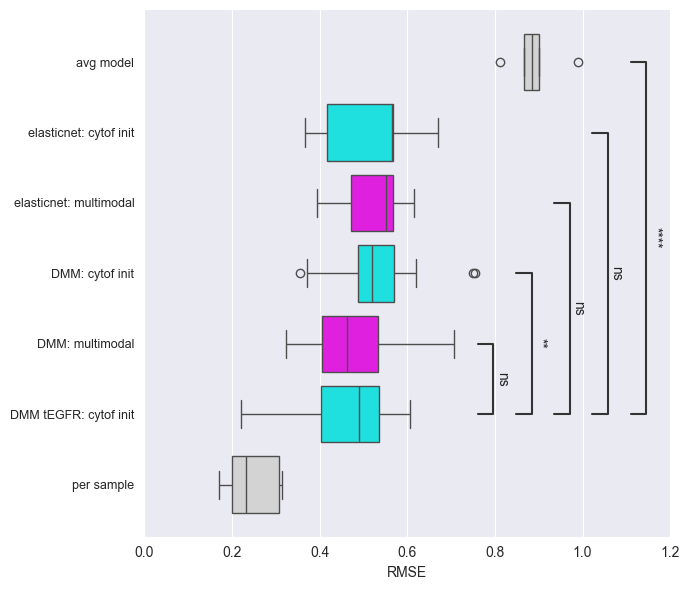

In [66]:
from statannotations.Annotator import Annotator

# --- build (or trim) comparisons to those present in the data ---
requested_comparisons = [
    ("DMM tEGFR: cytof init", "DMM: cytof init"),          # tEGFR vs base DMM
    ("DMM tEGFR: cytof init", "DMM: multimodal"),          # tEGFR vs base DMM
    ("DMM tEGFR: cytof init", "elasticnet: cytof init"),   # tEGFR vs elasticnet
    ("DMM tEGFR: cytof init", "elasticnet: multimodal"),   # tEGFR vs elasticnet
    ("DMM tEGFR: cytof init", "avg model"),   # tEGFR vs avg model
]

present = set(plot_df["display_group"].unique())
comparisons = [(a, b) for (a, b) in requested_comparisons if a in present and b in present]
if not comparisons:
    print("No valid comparisons found in data; check labels.")

# --- plot ---
plt.figure(figsize=(7, 6))
ax = sns.boxplot(
    data=plot_df,
    y="display_group",
    x="rmse",
    order=[lbl for lbl in order if lbl in present],  # keep order but drop absent
    palette=palette,
)

# --- add stats annotations (Mann–Whitney U, stars) ---
annotator = Annotator(
    ax, comparisons, data=plot_df,
    x="rmse", y="display_group",
    order=[lbl for lbl in order if lbl in present],
    orient='h'  # <— crucial for horizontal boxplots
)
annotator.configure(
    test='Mann-Whitney', text_format='star',
    loc='inside', line_offset=0.04, line_height=0.04, show_test_name=True
)
annotator.apply_and_annotate()

plt.yticks(fontsize=9)
plt.xlabel("RMSE")
plt.ylabel("")
plt.xlim(0, 1.2)
sns.despine()
plt.tight_layout()
# plt.savefig("RMSE_fig3_relevant_contexts_reduced.svg", bbox_inches="tight")

50 50
50 50
50 5
50 5
50 5
50 5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

DMM: multimodal vs. DMM tEGFR: cytof init: Custom statistical test, P_val:1.000e+00
DMM tEGFR: cytof init vs. per sample: Custom statistical test, P_val:2.166e-03
DMM: cytof init vs. DMM tEGFR: cytof init: Custom statistical test, P_val:1.973e-04
elasticnet: multimodal vs. DMM tEGFR: cytof init: Custom statistical test, P_val:1.000e+00
elasticnet: cytof init vs. DMM tEGFR: cytof init: Custom statistical test, P_val:1.000e+00
avg model vs. DMM tEGFR: cytof init: Custom statistical test, P_val:3.450e-06


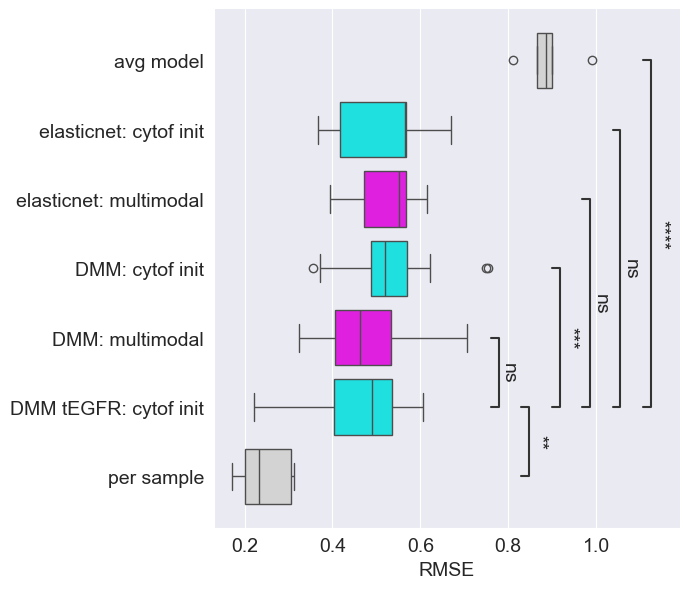

In [67]:
from scipy.stats import mannwhitneyu, wilcoxon
from statannotations.Annotator import Annotator
import statsmodels.stats.multitest as smm
import numpy as np
import pandas as pd

# --- pairs you want to test ---
requested_pairs = [
    ("DMM tEGFR: cytof init", "DMM: cytof init"),          # tEGFR vs base DMM
    ("DMM tEGFR: cytof init", "DMM: multimodal"),          # tEGFR vs base DMM
    ("DMM tEGFR: cytof init", "elasticnet: cytof init"),   # tEGFR vs elasticnet
    ("DMM tEGFR: cytof init", "elasticnet: multimodal"),   # tEGFR vs elasticnet
    ("DMM tEGFR: cytof init", "avg model"),   # tEGFR vs avg model
    ("DMM tEGFR: cytof init", "per sample"),   # tEGFR vs per sample
]

present_labels = set(plot_df["display_group"].unique())
pairs = [(a, b) for (a, b) in requested_pairs if a in present_labels and b in present_labels]
if not pairs:
    raise ValueError("No valid comparison pairs found in the data.")

def arrays_for_pair(a_label: str, b_label: str):
    """Return (a_vals, b_vals, paired) aligned as requested:
       - DMM–DMM: align on ['samples','job']
       - DMM–ElasticNet: align on ['samples'] only
    """
    a_df = plot_df.loc[plot_df["display_group"] == a_label, ["samples", "job", "rmse"]].copy()
    b_df = plot_df.loc[plot_df["display_group"] == b_label, ["samples", "job", "rmse"]].copy()

    a_is_dmm = a_label.startswith("DMM")
    b_is_dmm = b_label.startswith("DMM")
    paired = (a_is_dmm and b_is_dmm)

    if paired:
        # Align on (samples, job) to ensure same order
        merged = pd.merge(
            a_df.rename(columns={"rmse": "rmse_a"}),
            b_df.rename(columns={"rmse": "rmse_b"}),
            on=["samples", "job"],
            how="inner",
            validate="one_to_one"
        ).sort_values(["samples", "job"])
        a_vals = merged["rmse_a"].to_numpy()
        b_vals = merged["rmse_b"].to_numpy()
    else:
        # Aggregate over jobs for DMMs and compare same sample size (5 vs 5, i.e. CV split)
        a_df2 = a_df.sort_values(["samples"])
        b_df2 = b_df.sort_values(["samples"])
        a_vals = a_df2["rmse"].to_numpy()
        b_vals = b_df2["rmse"].to_numpy()

    return a_vals, b_vals, paired

# --- compute p-values with mixed tests ---
pvalues = []
valid_pairs = []
for a, b in pairs:
    a_vals, b_vals, paired = arrays_for_pair(a, b)

    # drop NaNs just in case
    a_vals = a_vals[~np.isnan(a_vals)]
    b_vals = b_vals[~np.isnan(b_vals)]

    print(len(a_vals), len(b_vals))

    if paired:
        # Wilcoxon needs equal length and same pairing; we already merged inner-join.
        if len(a_vals) == 0 or len(b_vals) == 0:
            continue
        try:
            stat, p = wilcoxon(a_vals, b_vals, alternative="two-sided")
        except ValueError:
            # happens if all diffs are zero and zero_method='wilcox' drops everything
            p = 1.0
    else:
        if len(a_vals) == 0 or len(b_vals) == 0:
            continue
        stat, p = mannwhitneyu(a_vals, b_vals, alternative="two-sided")

    pvalues.append(p)
    valid_pairs.append((a, b))

if not pvalues:
    raise ValueError("All comparisons were empty after alignment. Check labels and data.")

# --- (optional) multiple testing correction ---
APPLY_FDR = True
if APPLY_FDR:
    reject, pvals_corrected, _, _ = smm.multipletests(pvalues, method="bonferroni")
    pvals_for_plot = pvals_corrected.tolist()
else:
    pvals_for_plot = pvalues

# --- plot ---
ordered_labels = [lbl for lbl in order if lbl in present_labels]
plt.figure(figsize=(7, 6))
ax = sns.boxplot(
    data=plot_df,
    y="display_group", x="rmse",
    order=ordered_labels,
    palette=palette,
)


# --- annotate with the (corrected) p-values ---
annot = Annotator(
    ax, valid_pairs,
    data=plot_df, x="rmse", y="display_group",
    order=ordered_labels,
    orient='h'
)
annot.set_pvalues_and_annotate(pvals_for_plot)
# Set font sizes
ax.set_xlabel("RMSE", fontsize=14)
ax.set_ylabel("", fontsize=14)

# Tick labels
ax.tick_params(axis='both', labelsize=14)

# Despine and tighten
sns.despine()
plt.tight_layout()

# Legend (if added) fontsize
legend = ax.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(14)
    legend.get_title().set_fontsize(14)

# Annotation font size (statannotations)
for child in ax.get_children():
    if hasattr(child, "get_fontsize"):  # text objects
        child.set_fontsize(14)

plt.tight_layout()
# plt.savefig("RMSE_fig3_relevant_contexts_reduced_stattests_v4.svg", bbox_inches="tight")
plt.show()